# Pump_BuildUp 진행 중 Robot_Num 변경 시각화

`train_pump.ipynb`의 `Wagon_Block_ID`는 **Robot_Num 변경 또는 Pump_BuildUp 변경** 시점마다 블록을 새로 끊는다.

이 노트북은 "Robot_Num이 바뀌는 순간, 그 로봇 산하 펌프 중 하나라도 `Pump_BuildUp==1`(가동 중)인 경우"가
실제로 얼마나 자주 있는지, 그리고 어떤 모양으로 겹치는지 raw 데이터로 직접 확인한다.

- 이 비율이 크면 → 기존 `Wagon_Block_ID` 방식은 가동 사이클을 로봇 이동 때문에 중간에 계속 쪼갠다는 뜻.
- → 이번 이상탐지 피처 설계는 `Pump_BuildUp` 단독 기준으로 블록을 리셋해야 한다 (프로젝트 브리프 §4 원칙).

In [1]:
import os
import sys

ROOT_DIR = os.path.dirname(os.getcwd())  # parkkt/ 의 부모 = 저장소 루트
sys.path.insert(0, ROOT_DIR)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor

ENV_PATH = os.path.join(ROOT_DIR, ".env")

## 1. 설정

로봇(RB1/RB2) 산하 헤드(HD1~4)에 걸린 펌프들. **P8/I8은 실존하지 않는 스페어 태그라 제외**(P1~P7, I1~I7만 실제 사용).

In [2]:
START_TIME = "-24h"
END_TIME = "now()"

# Robot -> 소속 Head -> Pump 매핑 (프로젝트 브리프 매핑 이미지 기준)
# RB1: HD1(P1,P2) + HD2(P3,P4) / RB2: HD3(P5,P6) + HD4(P7)
ROBOT_PUMPS = {
    "RB1_Robot_Num": ["Pump_BuildUp_P1", "Pump_BuildUp_P2", "Pump_BuildUp_P3", "Pump_BuildUp_P4"],
    "RB2_Robot_Num": ["Pump_BuildUp_P5", "Pump_BuildUp_P6", "Pump_BuildUp_P7"],
}

## 2. 데이터 가져오기

In [3]:
extractor = LogExtractor(env_path=ENV_PATH)

target_tags = list(ROBOT_PUMPS.keys()) + [p for pumps in ROBOT_PUMPS.values() for p in pumps]
raw_df = extractor.get_data(start_time=START_TIME, end_time=END_TIME, target_tags=target_tags)

df = raw_df.ffill().fillna(0)
df.shape

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-21T10:30:34.412406+00:00 ~ 2026-09-22T10:30:34.412426+00:00
   태그 9개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-21T10:20:34Z ~ 2026-09-21T16:20:34Z ... 

4573행
📦 [Chunk] 2026-09-21T16:20:34Z ~ 2026-09-21T22:20:34Z ... 

984행
📦 [Chunk] 2026-09-21T22:20:34Z ~ 2026-09-22T04:20:34Z ... 

6097행
📦 [Chunk] 2026-09-22T04:20:34Z ~ 2026-09-22T10:20:34Z ... 

6383행
📦 [Chunk] 2026-09-22T10:20:34Z ~ 2026-09-22T10:30:34Z ... 

116행
✅ 통합 완료 — 18027행 × 10컬럼


(18027, 10)

## 3. "BuildUp 도중 Robot_Num 변경" 케이스 탐지

단순히 "그 순간 buildup=1이냐"만 보면 안 된다 — 로봇 도착과 buildup 시작이 같은 틱에 동시에
찍히는 경우가 대부분이라 그것까지 세면 과대집계된다. 그런 동시 케이스는 빼고,
**"이미 진행 중이던 buildup 한가운데서 robot_num이 바뀐" 경우만** 위반으로 센다.

In [4]:
def find_violations(df, robot_col, pump_cols):
    """robot_num이 바뀌는 순간, 그 펌프의 buildup이 **이전 행부터 이미** 1이었던 경우만 위반으로 본다.

    (로봇 도착과 동시에 buildup이 막 0->1로 시작된 경우는 제외 — BuildUp_Changed 하나만으로도
    이미 그 지점에서 블록이 갈리기 때문에, Wagon 기준을 얹어도 추가로 쪼개지는 게 없어 문제가 아니다.)
    """
    robot_changed = df[robot_col].diff() != 0
    curr_is_1 = df[pump_cols] == 1
    prev_was_1 = df[pump_cols].shift(1) == 1
    already_running = (prev_was_1 & curr_is_1).any(axis=1)
    return robot_changed & already_running

violation_masks = {}
summary_rows = []
for robot_col, pump_cols in ROBOT_PUMPS.items():
    v = find_violations(df, robot_col, pump_cols)
    violation_masks[robot_col] = v
    total_changes = (df[robot_col].diff() != 0).sum()
    summary_rows.append({
        "robot": robot_col,
        "robot_num_변경_횟수": int(total_changes),
        "진짜_위반_횟수": int(v.sum()),
        "위반_비율": round(v.sum() / total_changes, 4) if total_changes else None,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,robot,robot_num_변경_횟수,진짜_위반_횟수,위반_비율
0,RB1_Robot_Num,4417,48,0.0109
1,RB2_Robot_Num,4417,267,0.0604


In [5]:
# 아래부터는 "진짜 도중에 바뀐" true_violation 케이스만 본다 (동시 케이스는 문제가 아니므로 제외)
events = []
for robot_col, pump_cols in ROBOT_PUMPS.items():
    v = violation_masks[robot_col]
    for ts in df.index[v]:
        active_pumps = [c.replace("Pump_BuildUp_", "") for c in pump_cols if df.loc[ts, c] == 1]
        events.append({
            "time": ts,
            "robot": robot_col,
            "robot_num": df.loc[ts, robot_col],
            "active_pumps": ", ".join(active_pumps),
        })

events_df = pd.DataFrame(events).sort_values("time").reset_index(drop=True)

OUT_DIR = os.path.join(os.getcwd(), "analysis_out")
os.makedirs(OUT_DIR, exist_ok=True)
events_df.to_csv(os.path.join(OUT_DIR, "robot_num_change_during_buildup_events.csv"),
                  index=False, encoding="utf-8-sig")

print(f"진짜 위반 {len(events_df)}건 -> analysis_out/robot_num_change_during_buildup_events.csv 저장")
events_df.head(20)

진짜 위반 315건 -> analysis_out/robot_num_change_during_buildup_events.csv 저장


,time,robot,robot_num,active_pumps
0,2026-09-21 20:13:08.648688,RB2_Robot_Num,24.0,P7
1,2026-09-21 20:14:28.001748,RB2_Robot_Num,30.0,P7
2,2026-09-21 20:17:01.619480,RB2_Robot_Num,42.0,P7
3,2026-09-21 20:17:26.543372,RB2_Robot_Num,2.0,"P5, P7"
4,2026-09-21 20:18:05.263562,RB2_Robot_Num,5.0,"P5, P7"
5,2026-09-21 20:21:25.532455,RB2_Robot_Num,20.0,P7
6,2026-09-21 20:25:47.422009,RB2_Robot_Num,40.0,P7
7,2026-09-21 20:28:51.983490,RB2_Robot_Num,12.0,"P5, P7"
8,2026-09-21 20:31:30.184785,RB2_Robot_Num,24.0,P7
9,2026-09-21 20:32:49.641404,RB2_Robot_Num,30.0,P7


## 4. 전체 타임라인 — Robot_Num vs 소속 펌프 BuildUp

빨간 세로선 = "BuildUp 도중 Robot_Num이 바뀐" 시점.

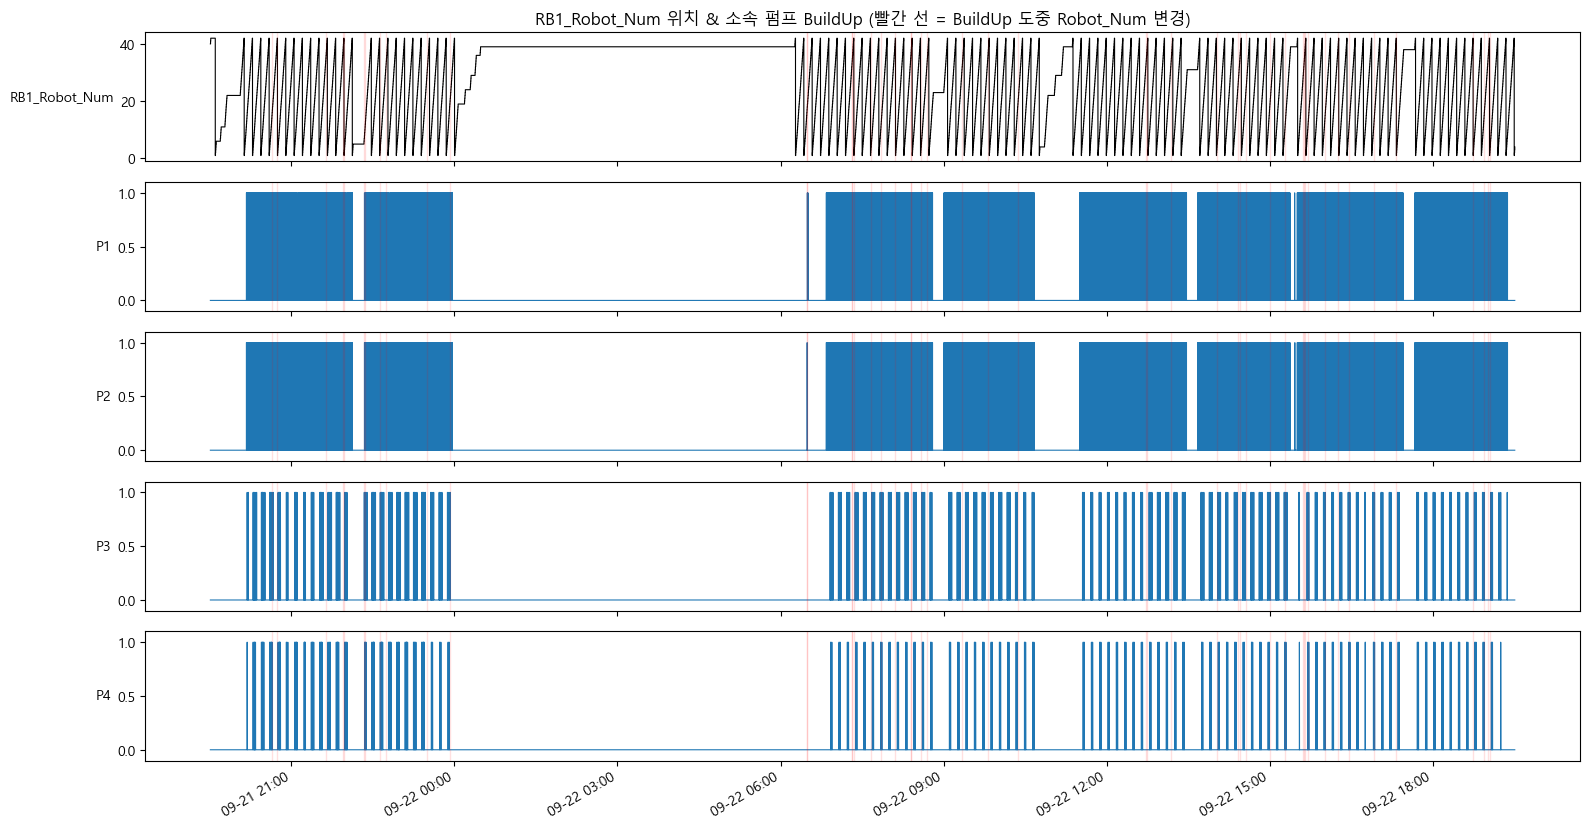

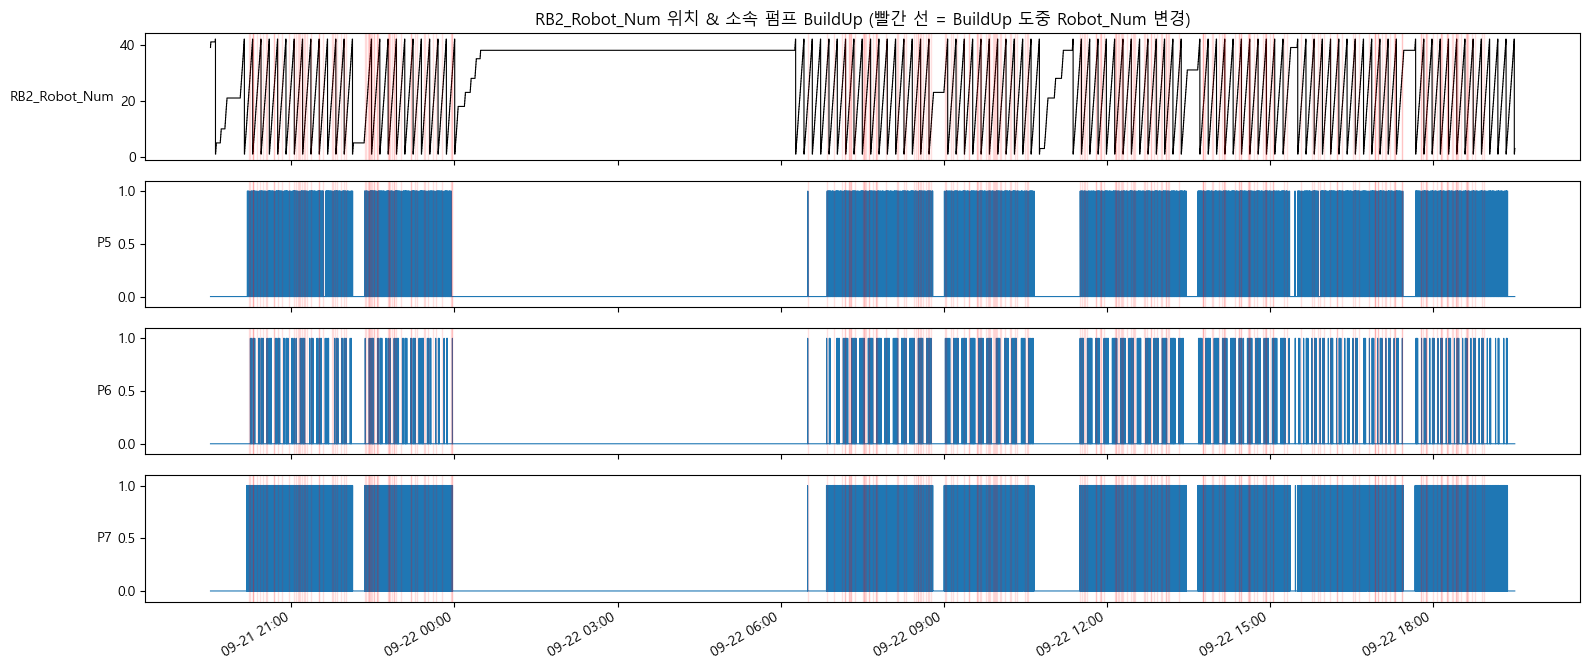

In [6]:
def plot_robot_timeline(df, robot_col, pump_cols, violation_mask, title):
    fig, axes = plt.subplots(len(pump_cols) + 1, 1, figsize=(16, 2 + 1.6 * len(pump_cols)), sharex=True)

    axes[0].step(df.index, df[robot_col], where="post", color="black", linewidth=0.8)
    axes[0].set_ylabel(robot_col, rotation=0, ha="right", va="center")
    axes[0].set_title(title)

    for ax, pump_col in zip(axes[1:], pump_cols):
        ax.step(df.index, df[pump_col], where="post", color="tab:blue", linewidth=0.8)
        ax.set_ylabel(pump_col.replace("Pump_BuildUp_", ""), rotation=0, ha="right", va="center")
        ax.set_ylim(-0.1, 1.1)

    violation_times = df.index[violation_mask]
    for ax in axes:
        for t in violation_times:
            ax.axvline(t, color="red", alpha=0.12, linewidth=1)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig

for robot_col, pump_cols in ROBOT_PUMPS.items():
    plot_robot_timeline(
        df, robot_col, pump_cols, violation_masks[robot_col],
        f"{robot_col} 위치 & 소속 펌프 BuildUp (빨간 선 = BuildUp 도중 Robot_Num 변경)",
    )
    plt.show()

## 5. 개별 케이스 확대

로봇별 처음 5건씩, 변경 시점 앞뒤 **20초**만 잘라서 본다. 실제 데이터 포인트(틱)마다 점을 찍고,
로봇번호 값도 점 옆에 숫자로 달아서 몇 번째 틱에서 바뀌는지 바로 보이게 한다.

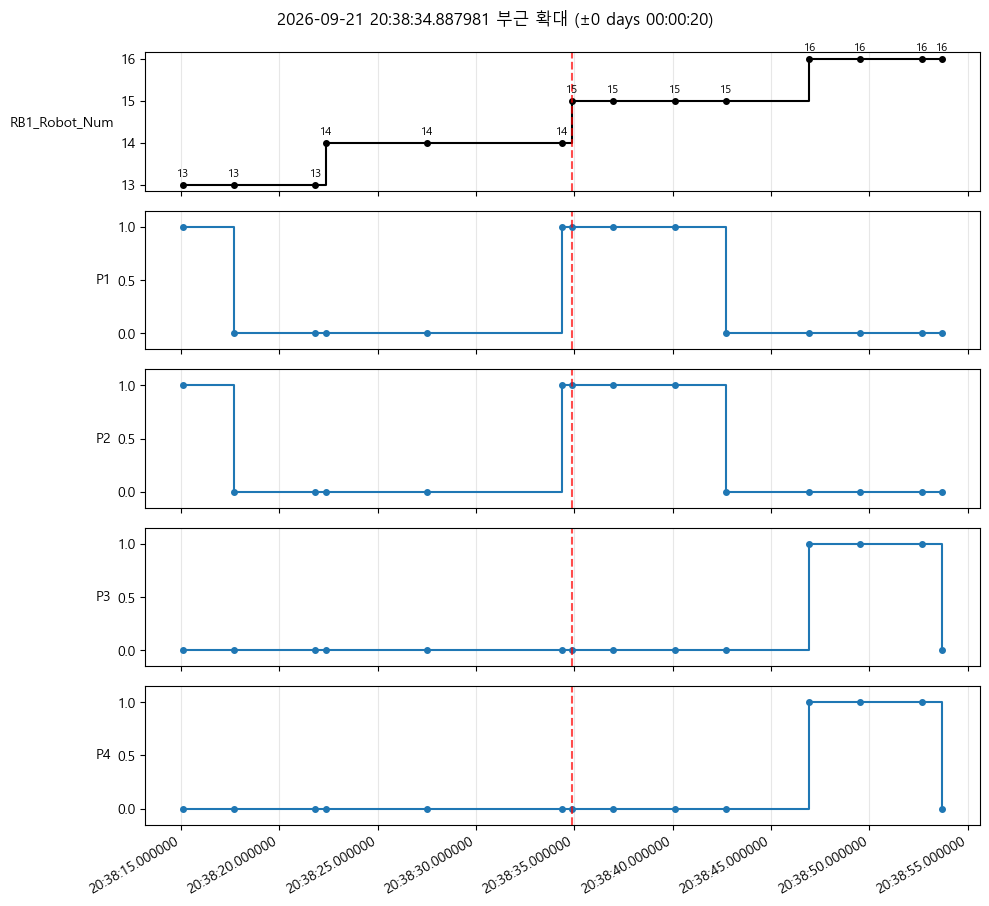

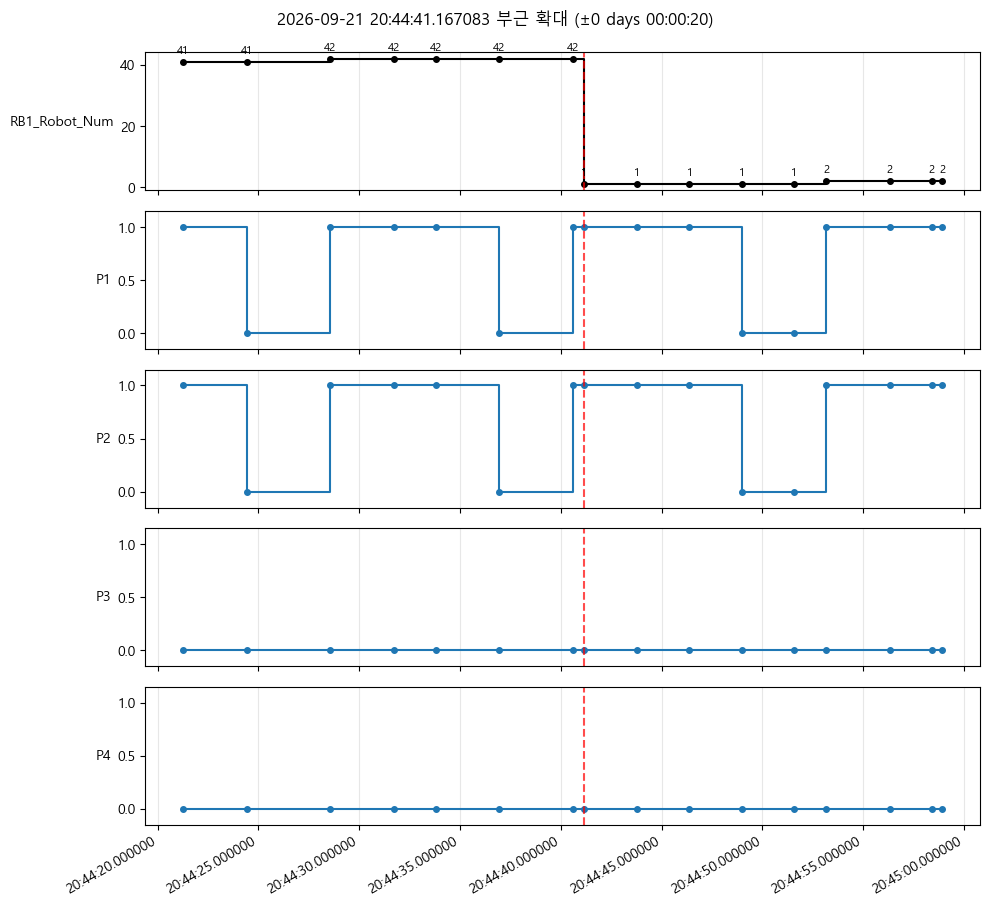

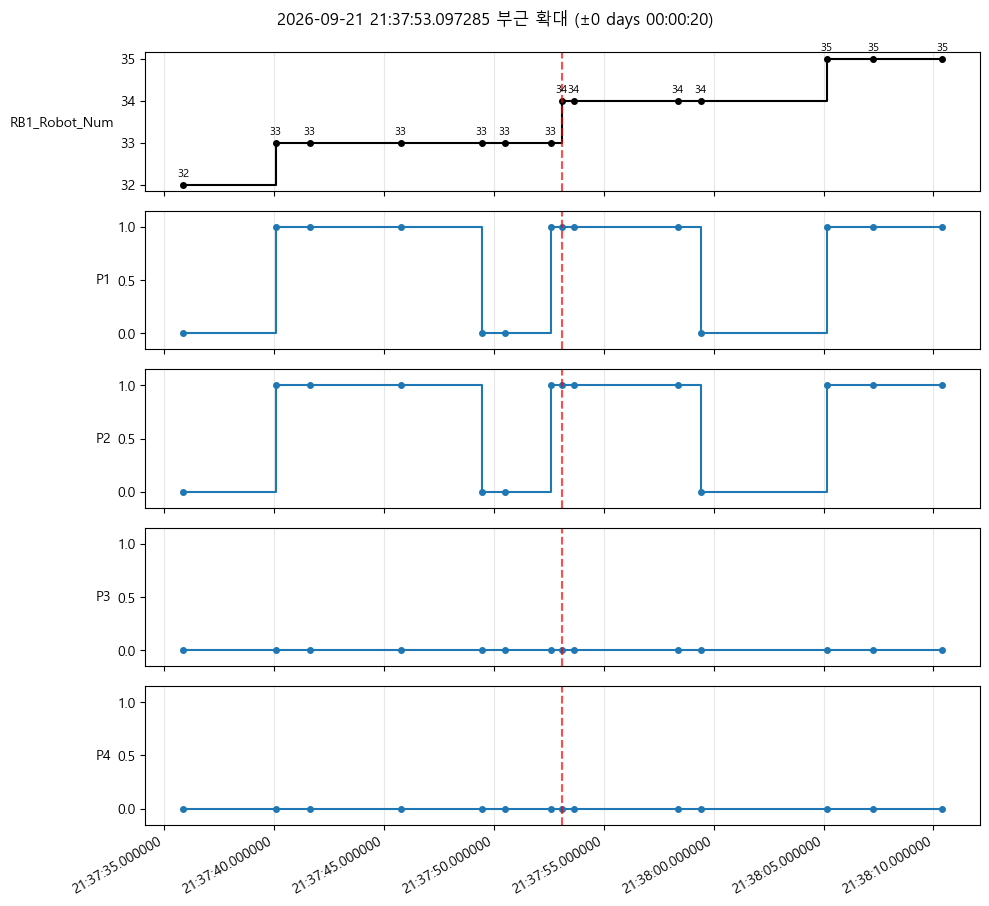

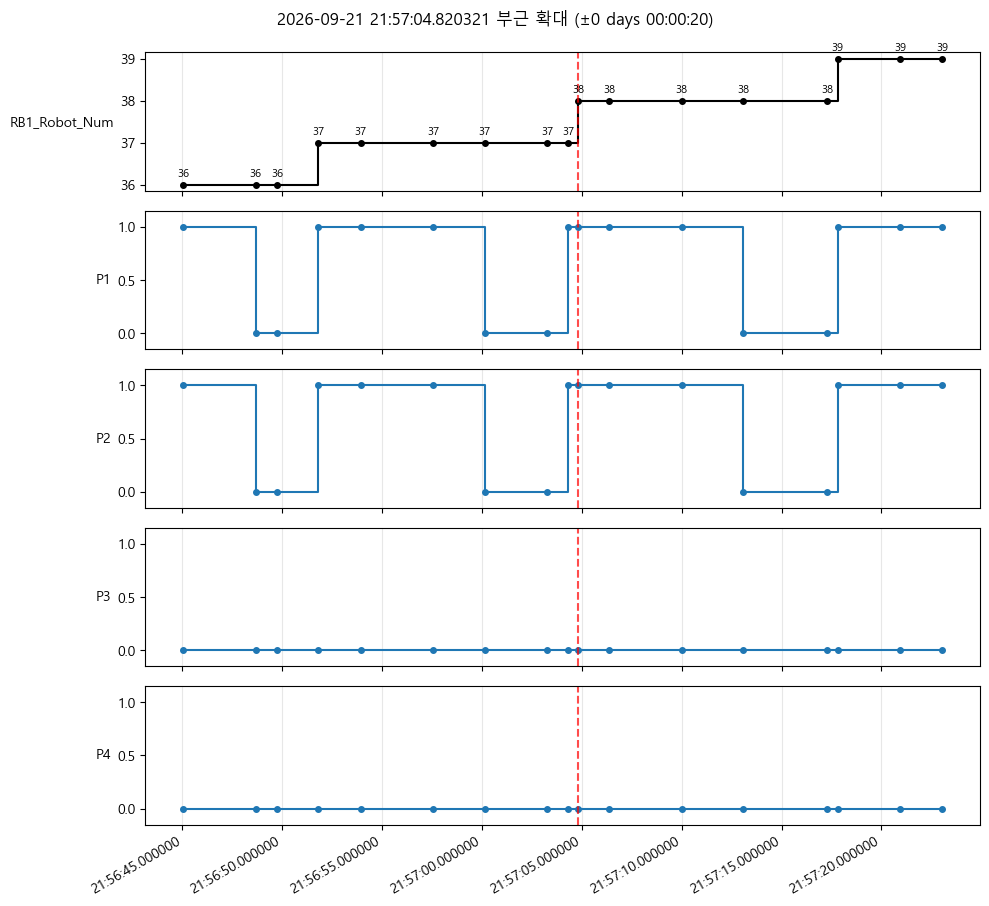

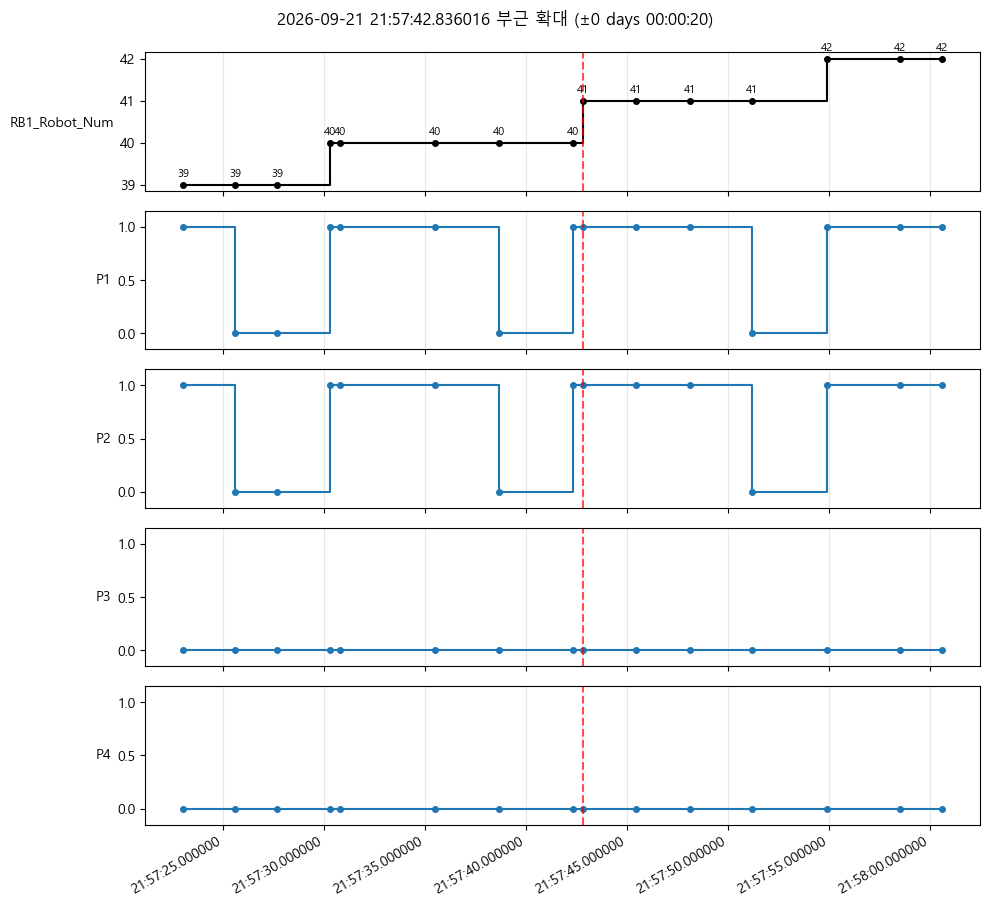

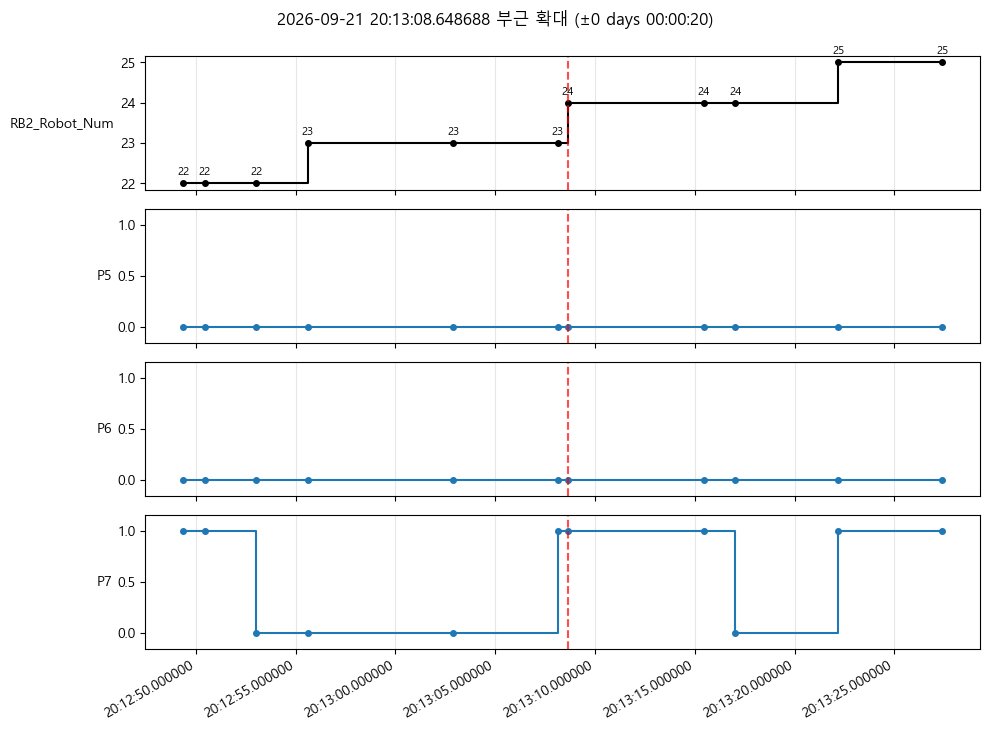

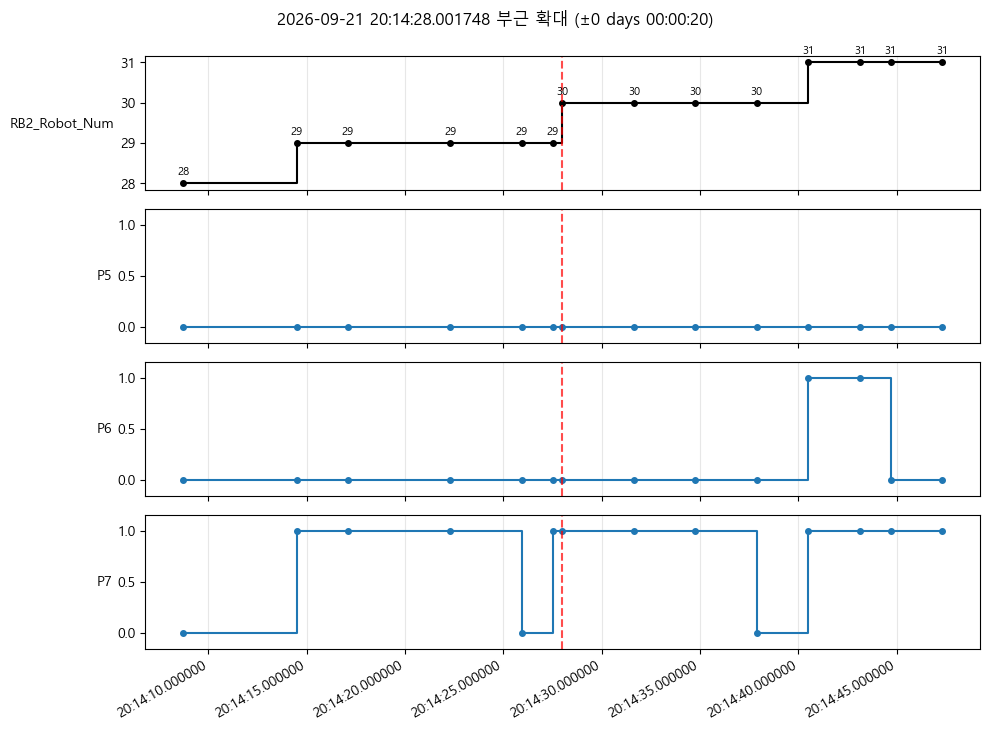

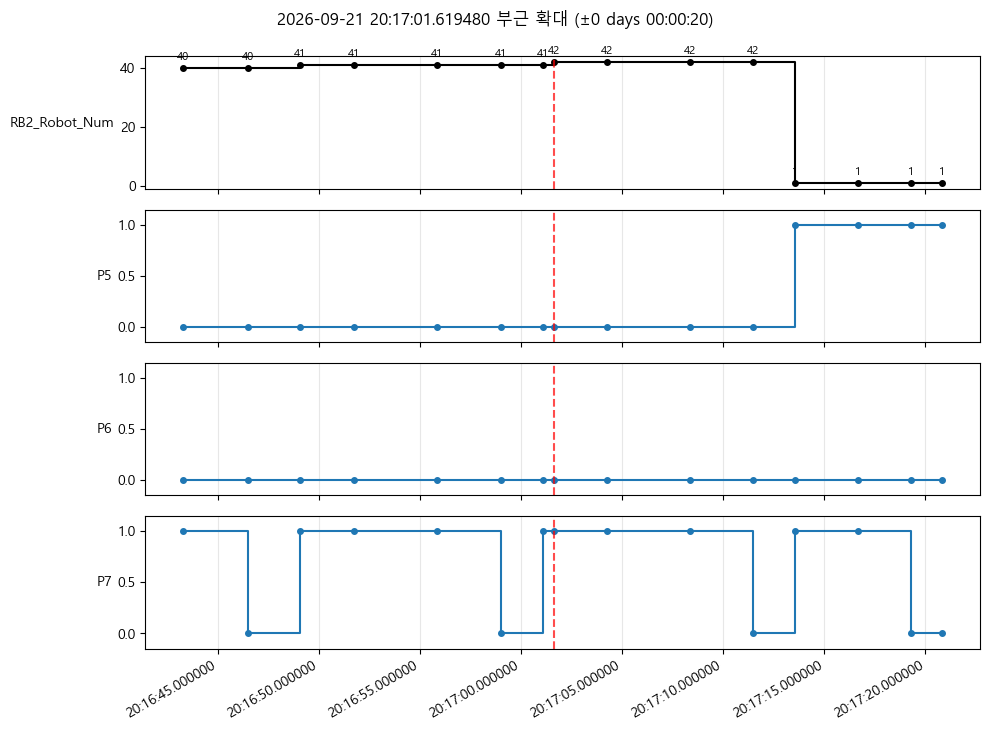

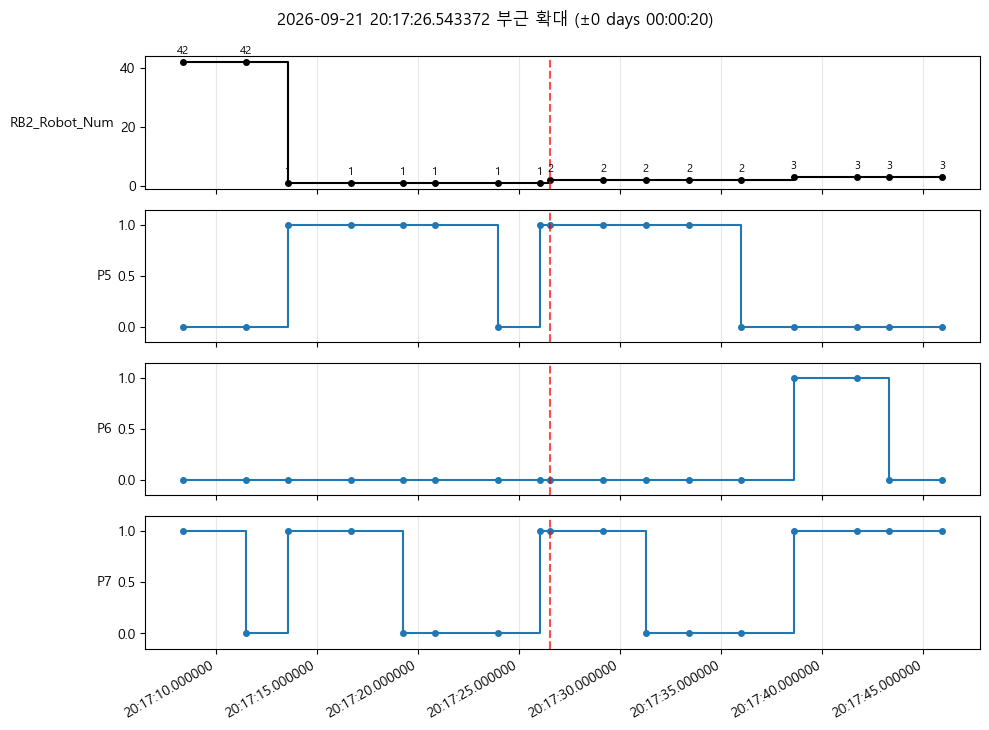

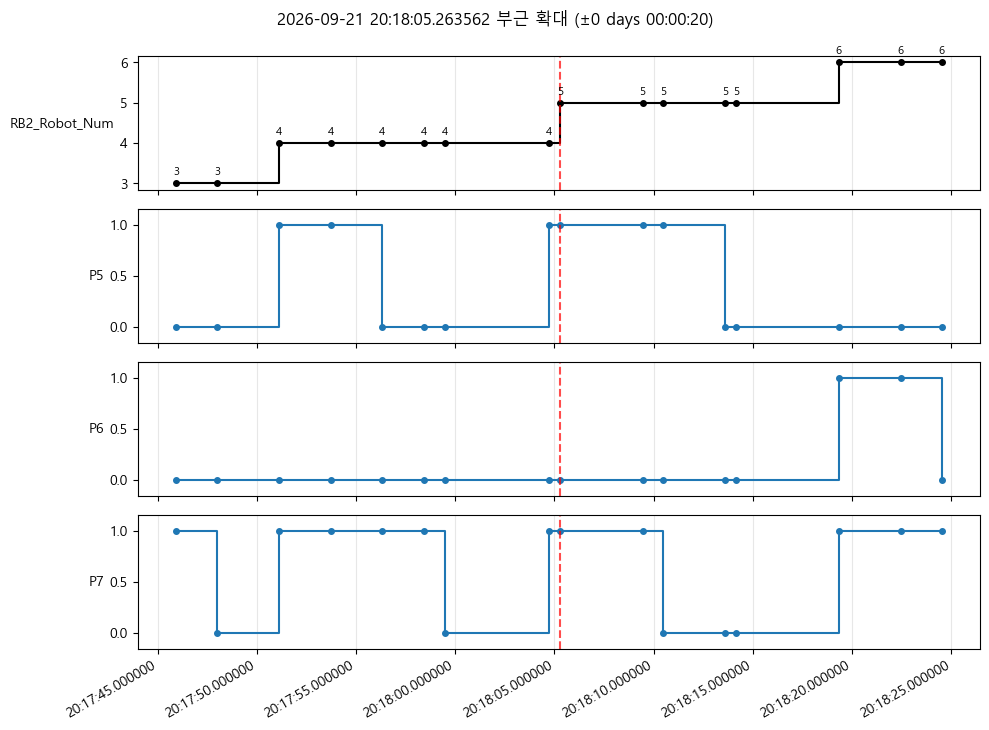

In [7]:
def plot_zoom(df, robot_col, pump_cols, center_time, window=pd.Timedelta(seconds=20)):
    seg = df.loc[center_time - window: center_time + window]
    fig, axes = plt.subplots(len(pump_cols) + 1, 1, figsize=(10, 2 + 1.8 * len(pump_cols)), sharex=True)

    ax0 = axes[0]
    ax0.step(seg.index, seg[robot_col], where="post", color="black", marker="o", markersize=4)
    ax0.set_ylabel(robot_col, rotation=0, ha="right", va="center")
    for t, y in zip(seg.index, seg[robot_col]):
        ax0.annotate(f"{y:g}", (t, y), textcoords="offset points", xytext=(0, 6),
                     fontsize=8, ha="center")

    for ax, pump_col in zip(axes[1:], pump_cols):
        ax.step(seg.index, seg[pump_col], where="post", color="tab:blue", marker="o", markersize=4)
        ax.set_ylabel(pump_col.replace("Pump_BuildUp_", ""), rotation=0, ha="right", va="center")
        ax.set_ylim(-0.15, 1.15)

    for ax in axes:
        ax.axvline(center_time, color="red", linestyle="--", alpha=0.7)
        ax.grid(True, axis="x", alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S.%f"))
    fig.autofmt_xdate()
    fig.suptitle(f"{center_time} 부근 확대 (±{window})")
    fig.tight_layout()
    return fig

N_EXAMPLES = 5
for robot_col, pump_cols in ROBOT_PUMPS.items():
    times = df.index[violation_masks[robot_col]][:N_EXAMPLES]
    for t in times:
        plot_zoom(df, robot_col, pump_cols, t)
        plt.show()